# Bước 8: Launch & Maintain - Khớp lệnh 2026 (Blind Test)

Notebook này đóng vai trò là bài kiểm tra cuối cùng. Chúng ta sẽ lấy mô hình SVR siêu việt đã Train bằng dữ liệu 2020-2025, và kiểm tra nó trên thực tế của Quý 1/2026 để đối chiếu xem biên độ biến động dự báo ôm sát thế nào so với biên độ thực.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Setting plotting aesthetics thiết lập phong cách tài chính
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 7)

In [2]:
def evaluate_inference(ticker="HPG", forecast_horizon=1):
    print(f"\n{'='*50}")
    print(f"PHÂN TÍCH INFERENCE 2026: {ticker}")
    print(f"{'='*50}")
    
    # 1. Load Data & Model
    base_dir = os.path.dirname(os.path.dirname(os.getcwd())) # Đi ra project root
    # Setup an explicit path in case relative path routing is wrong in jupyter
    if 'notebooks' not in os.getcwd(): 
        base_dir = os.path.dirname(os.path.dirname(os.path.abspath('')))
        
    # Manual fallback for Windows environment
    base_dir = r'C:\Users\thien\OneDrive\Tài liệu\tài liệu chuyên ngành\machine learning\Project\Project root'
    
    data_path = os.path.join(base_dir, 'data', 'processed', f'{ticker}_inference_processed.csv')
    model_path = os.path.join(base_dir, 'models', f'{ticker}_best_model.pkl')
    
    if not os.path.exists(data_path) or not os.path.exists(model_path):
        print(f"Không tìm thấy Data hoặc Model tại {data_path} / {model_path}")
        return None
        
    df = pd.read_csv(data_path)
    df.columns = [col.lower() for col in df.columns]
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')
    
    model = joblib.load(model_path)
    
    # 2. Xử lý Target cho dữ liệu Infer (Shift -1 nếu dự báo ngày mai)
    df['target'] = df['pct_return'].shift(-forecast_horizon) * 100 
    df = df.dropna(subset=['target'])
    
    # 3. Trích xuất Features
    features = ['rsi', 'macd_12_26_9', 'adx_14', 'vol_ratio', 'rs', 'alpha', 'inertia']
    available_features = [col for col in features if col in df.columns]
    X = df[available_features]
    y_true = df['target']
    
    # 4. Predict từ SVR đã fine-tune
    y_pred = model.predict(X)
    df['predicted_target'] = y_pred
    
    # 5. Đánh giá bằng Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"MAE trên Dữ liệu Blind Test (Quý 1/2026): {mae:.3f}%")
    print(f"RMSE trên Dữ liệu Blind Test: {rmse:.3f}%")
    
    # Làm thêm khả năng đo đúng hướng của lợi nhuận
    direction_match = (np.sign(y_true) == np.sign(y_pred)).mean()
    print(f"Tỉ lệ bắt đúng xu hướng Chiều lên/xuống ngày mai: {direction_match*100:.1f}%")
    
    # ==================
    # 6. BIỂU ĐỒ PHÂN TÍCH THỰC TẾ
    # ==================
    plt.figure(figsize=(15, 6))
    plt.plot(df.index, y_true, label='Biến động Thực tế (%)', color='blue', alpha=0.6, marker='o', linewidth=1)
    plt.plot(df.index, y_pred, label='SVR Dự Báo (%)', color='red', alpha=0.9, linestyle='dashed', linewidth=2)
    plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
    plt.title(f'Kịch bản Độ Nhạy Thị trường - {ticker} (2026)')
    plt.ylabel('% Biến động Ngày')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # ==================
    # 7. CHUỖI TÍCH LŨY ĐẦU TƯ
    # ==================
    # Giả sử ta vào vốn Mua & Giữ cổ phiếu thì Accumulative sum of returns
    cum_real = (1 + (y_true/100)).cumprod()
    cum_pred = (1 + (y_pred/100)).cumprod()
    
    plt.figure(figsize=(15, 6))
    plt.plot(df.index, cum_real, label='Tài khoản Thực tế (Hold)', color='blue', linewidth=2)
    plt.plot(df.index, cum_pred, label='Hành vi Mô phỏng từ Model', color='darkorange', linewidth=2, linestyle='dotted')
    plt.title(f'Tăng trưởng dòng vốn sức mạnh - {ticker} (Bắt đầu = 1.0)')
    plt.ylabel('Hệ số Tài khoản')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return df


PHÂN TÍCH INFERENCE 2026: HPG
MAE trên Dữ liệu Blind Test (Quý 1/2026): 1.519%
RMSE trên Dữ liệu Blind Test: 2.180%
Tỉ lệ bắt đúng xu hướng Chiều lên/xuống ngày mai: 44.8%


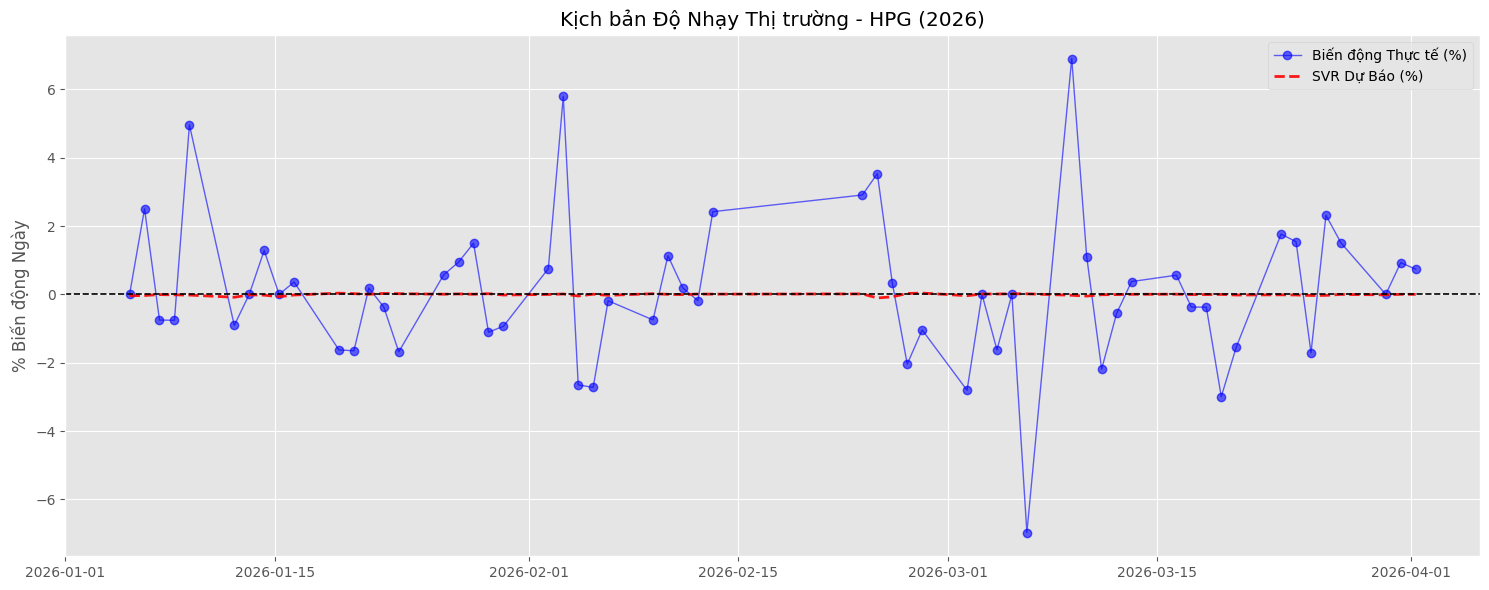

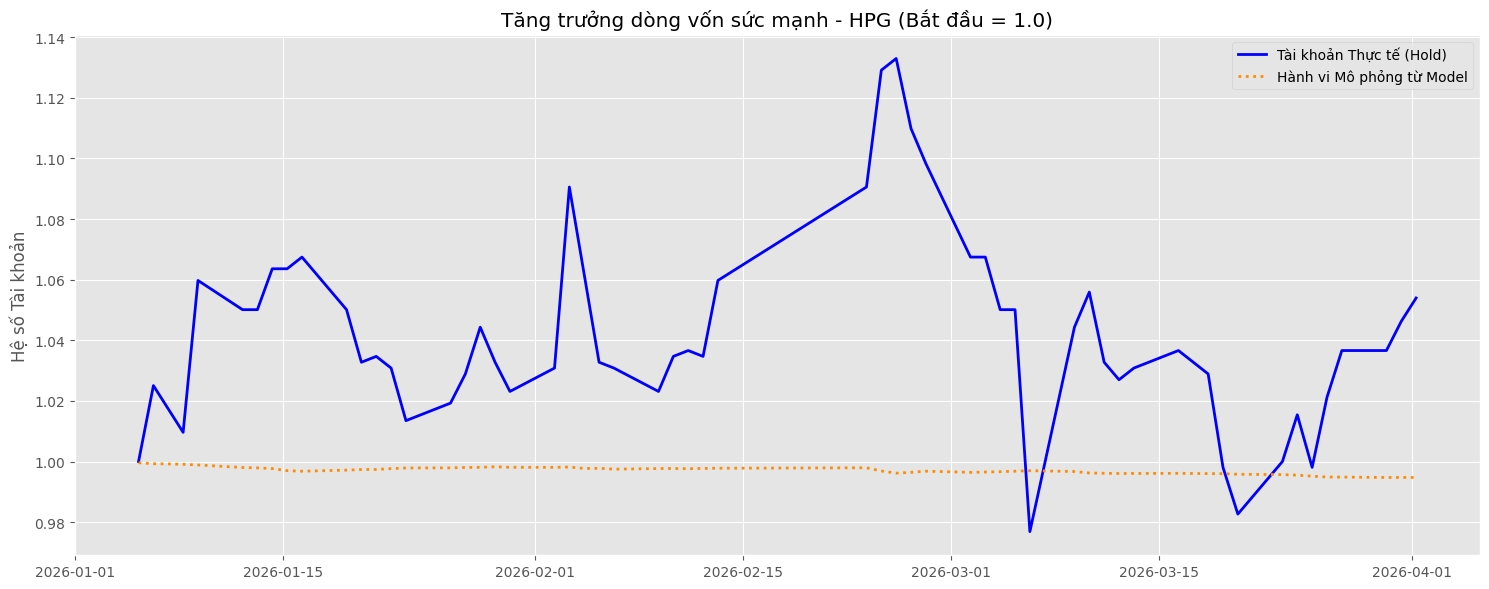

In [3]:
# Khởi động đánh giá HPG
df_hpg = evaluate_inference('HPG')


PHÂN TÍCH INFERENCE 2026: HSG
MAE trên Dữ liệu Blind Test (Quý 1/2026): 1.656%
RMSE trên Dữ liệu Blind Test: 2.172%
Tỉ lệ bắt đúng xu hướng Chiều lên/xuống ngày mai: 48.3%


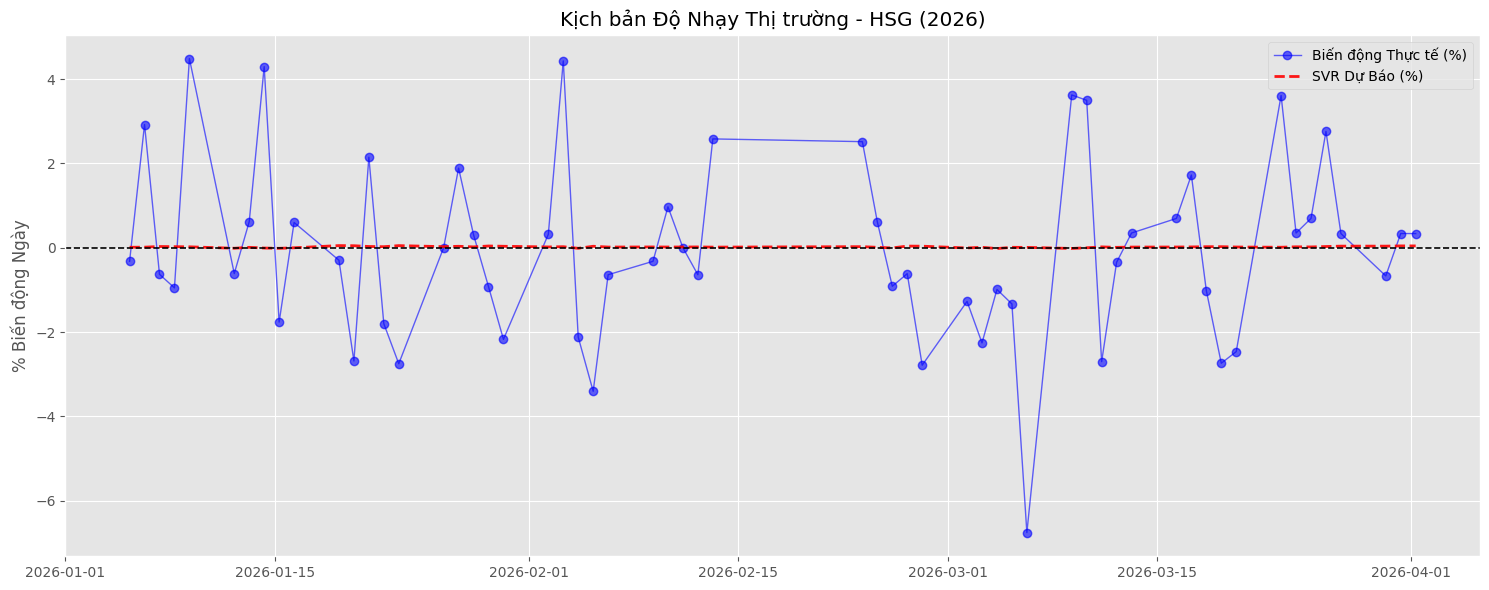

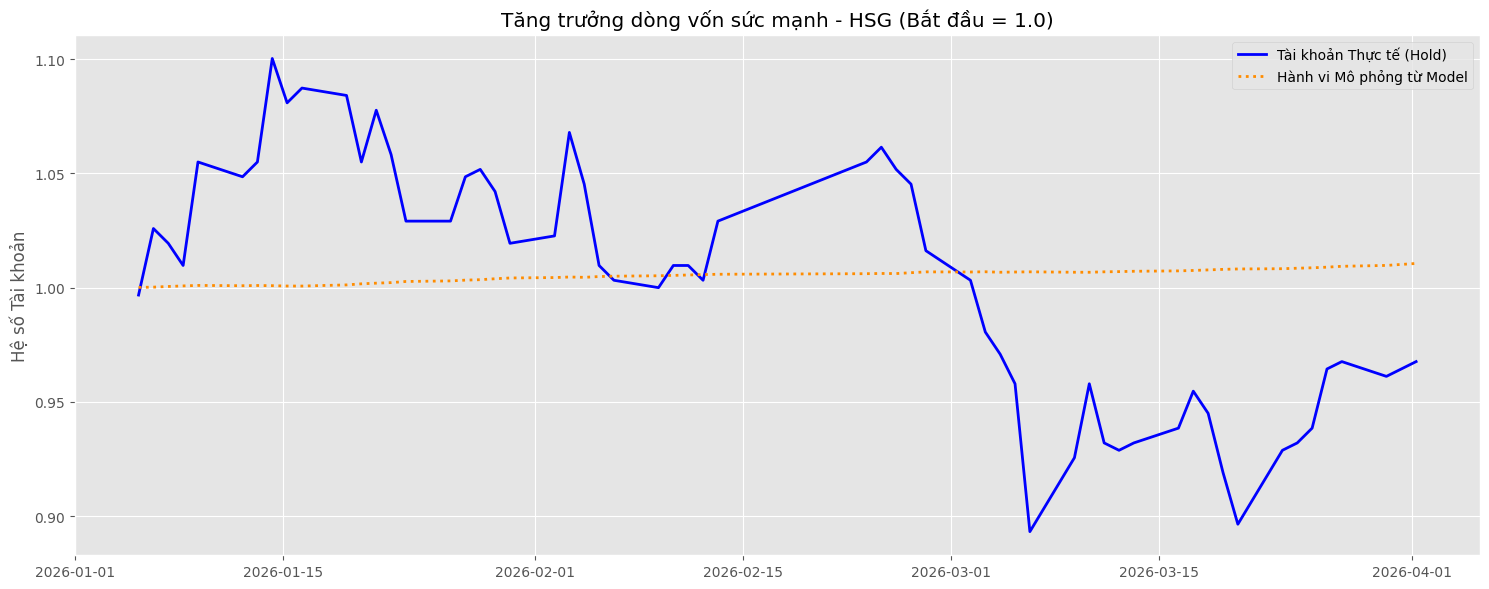

In [4]:
# Khởi động đánh giá HSG 
df_hsg = evaluate_inference('HSG')